In [2]:
%pip install git+https://github.com/KrishnaswamyLab/Multiscale_PHATE


  Cloning https://github.com/KrishnaswamyLab/Multiscale_PHATE to /private/var/folders/31/q5w1v97x6jn5j_msmdymm6nc0000gn/T/pip-req-build-sawm2i8y
  Running command git clone --filter=blob:none --quiet https://github.com/KrishnaswamyLab/Multiscale_PHATE /private/var/folders/31/q5w1v97x6jn5j_msmdymm6nc0000gn/T/pip-req-build-sawm2i8y
  Resolved https://github.com/KrishnaswamyLab/Multiscale_PHATE to commit fe2a904fb05425c0fedd0de0a5b8e11ff4bf0f91
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scprep

Note: you may need to restart the kernel to use updated packages.


In [4]:
import multiscale_phate as mp
import numpy as np
import pandas as pd

import scprep
import os

In [5]:
## Save data directory
data_dir = os.path.expanduser("~/multiscale_phate_data") # enter path to data directory here (this is where you want to save 10X data)
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)

file_name = '10X_pbmc_data.h5'
file_path = os.path.join(data_dir, file_name)

In [6]:
URL = 'https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc4k/pbmc4k_raw_gene_bc_matrices_h5.h5'

scprep.io.download.download_url(URL, file_path)

In [7]:
data = scprep.io.load_10X_HDF5(file_path, gene_labels='both')

data.head()

,RP11-34P13.3 (ENSG00000243485),FAM138A (ENSG00000237613),OR4F5 (ENSG00000186092),RP11-34P13.7 (ENSG00000238009),RP11-34P13.8 (ENSG00000239945),RP11-34P13.14 (ENSG00000239906),RP11-34P13.9 (ENSG00000241599),FO538757.3 (ENSG00000279928),FO538757.2 (ENSG00000279457),AP006222.2 (ENSG00000228463),...,AC007325.2 (ENSG00000277196),BX072566.1 (ENSG00000277630),AL354822.1 (ENSG00000278384),AC023491.2 (ENSG00000278633),AC004556.1 (ENSG00000276345),AC233755.2 (ENSG00000277856),AC233755.1 (ENSG00000275063),AC240274.1 (ENSG00000271254),AC213203.1 (ENSG00000277475),FAM231B (ENSG00000268674)
AAACCTGAGAAACCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGAAACCGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGAAACCTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGAAACGAG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGAAACGCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
data = scprep.filter.filter_library_size(data, cutoff=1000,  keep_cells='above')
data = scprep.filter.filter_rare_genes(data)

In [9]:
data_norm, libsize = scprep.normalize.library_size_normalize(data, return_library_size=True)


In [10]:
data_sqrt = np.sqrt(data_norm)

data_sqrt.head()

,RP11-34P13.7 (ENSG00000238009),FO538757.2 (ENSG00000279457),AP006222.2 (ENSG00000228463),RP4-669L17.10 (ENSG00000237094),RP11-206L10.9 (ENSG00000237491),LINC00115 (ENSG00000225880),FAM41C (ENSG00000230368),NOC2L (ENSG00000188976),KLHL17 (ENSG00000187961),PLEKHN1 (ENSG00000187583),...,MT-ND6 (ENSG00000198695),MT-CYB (ENSG00000198727),BX004987.4 (ENSG00000278704),AC145212.2 (ENSG00000274847),AC011043.1 (ENSG00000276256),AL592183.1 (ENSG00000273748),AC007325.4 (ENSG00000278817),AL354822.1 (ENSG00000278384),AC004556.1 (ENSG00000276345),AC240274.1 (ENSG00000271254)
AAACCTGAGAAGGCCT-1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,4.154662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGACAGACC-1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,6.573422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGATAGTCA-1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,6.449217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGCGCCTCA-1,0.0,0.0,0.0,0.0,2.077481,0.0,0.0,2.077481,0.0,0.0,...,0.0,5.876003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGAGGCATGGT-1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,3.661874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
mp_op = mp.Multiscale_PHATE(random_state=1)

levels = mp_op.fit(data_sqrt)

Calculating Multiscale PHATE tree...
  Calculating PCA...
  Calculated PCA in 32.00 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 49.91 seconds.
  Setting epsilon to 3.3186
  Setting merge threshold to 0.1821
  Calculating condensation...
  Calculated condensation in 4.70 seconds.
Calculated Multiscale PHATE tree in 87.16 seconds.
Computing gradient...
Identifying salient levels of resolution...


In [12]:
import pickle

# After you create mp_op (your msPHATE object)
with open('/Users/raghu/yale/data/long_covid_data_copy/Bcellcopy_msphate_object.pickle', 'wb') as handle:
    pickle.dump(mp_op, handle)

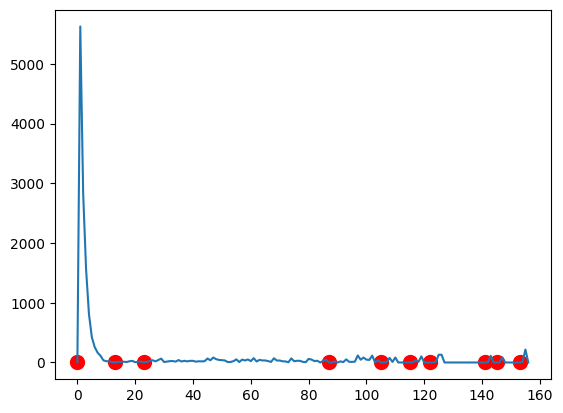

In [10]:
import matplotlib.pyplot as plt
ax = plt.plot(mp_op.gradient)
ax = plt.scatter(levels, mp_op.gradient[levels], c = 'r', s=100)

In [11]:
levels

[0, 13, 23, 87, 105, 115, 122, 141, 145, 153]

Calculating base visualization...
Calculated base visualization in 14.32 seconds.
Calculating tree...
Calculated tree in 0.93 seconds.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes3D: >

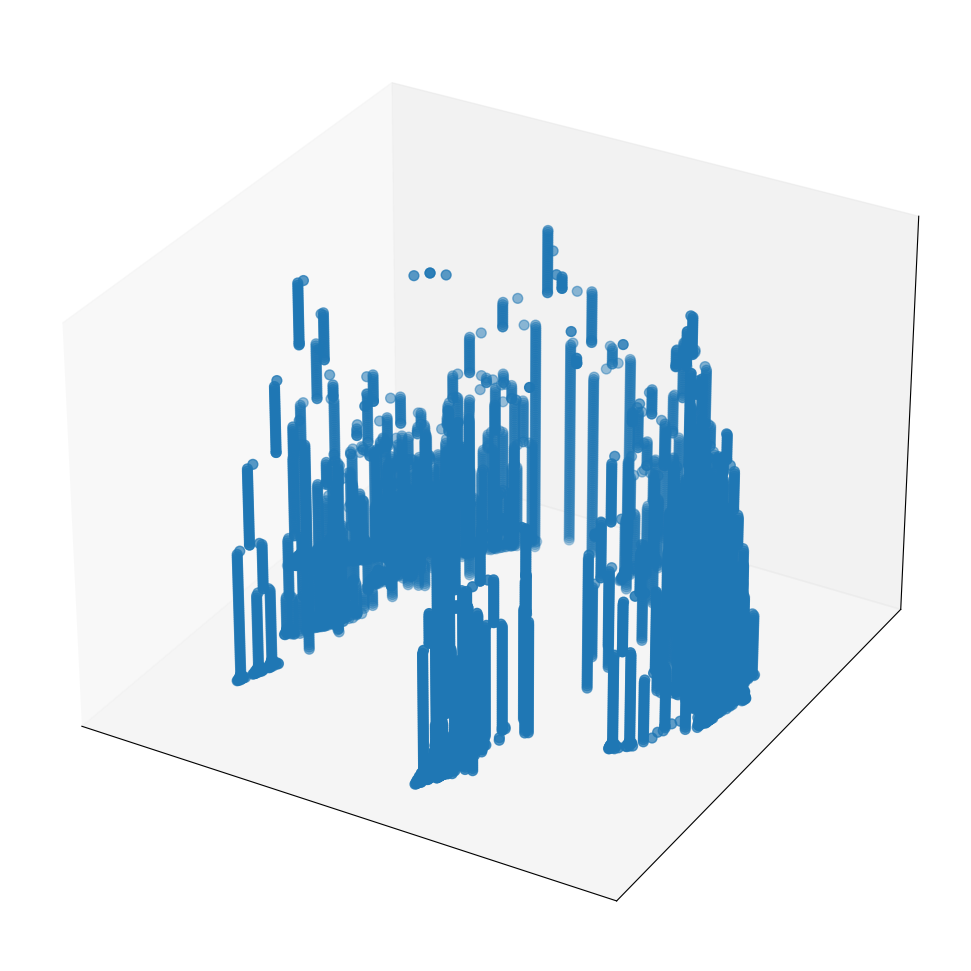

In [12]:
### building tree

tree = mp_op.build_tree()

scprep.plot.scatter3d(tree, s= 50,
                      fontsize=16, ticks=False, figsize=(10,10))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes3D: >

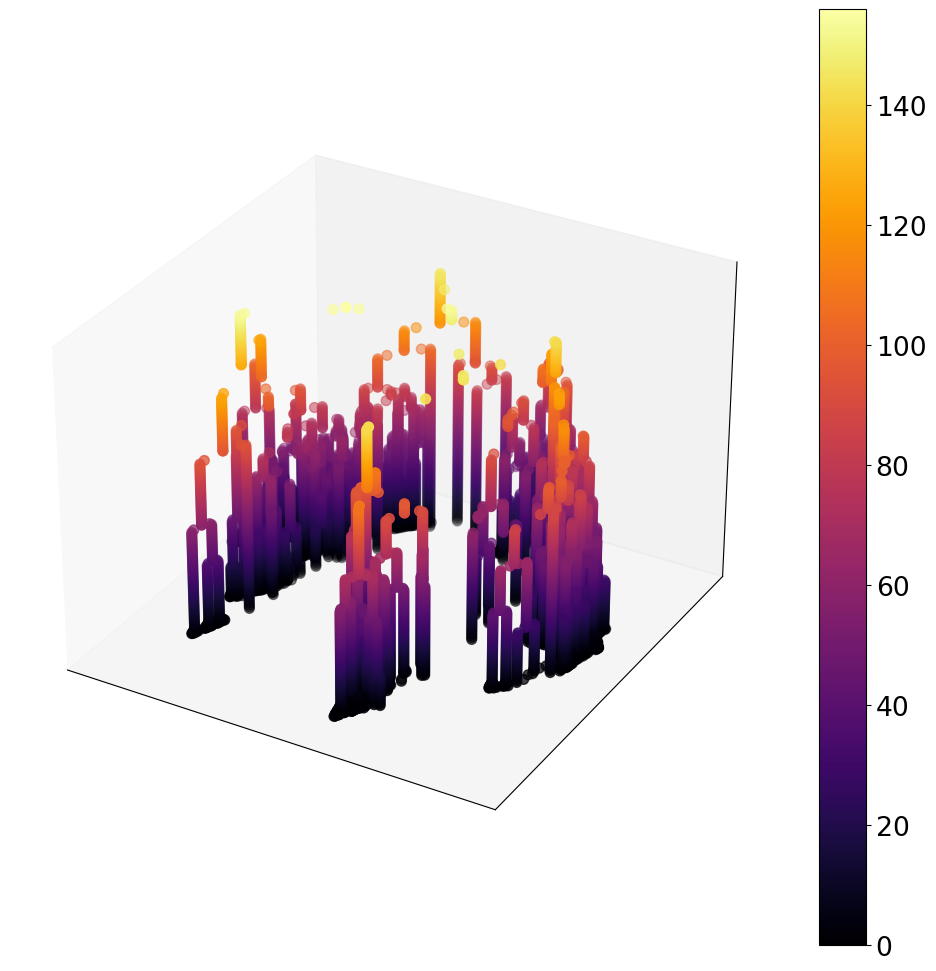

In [13]:
scprep.plot.scatter3d(tree, c = tree[:,2], s= 50,
                      fontsize=16, ticks=False, figsize=(10,10))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes3D: >

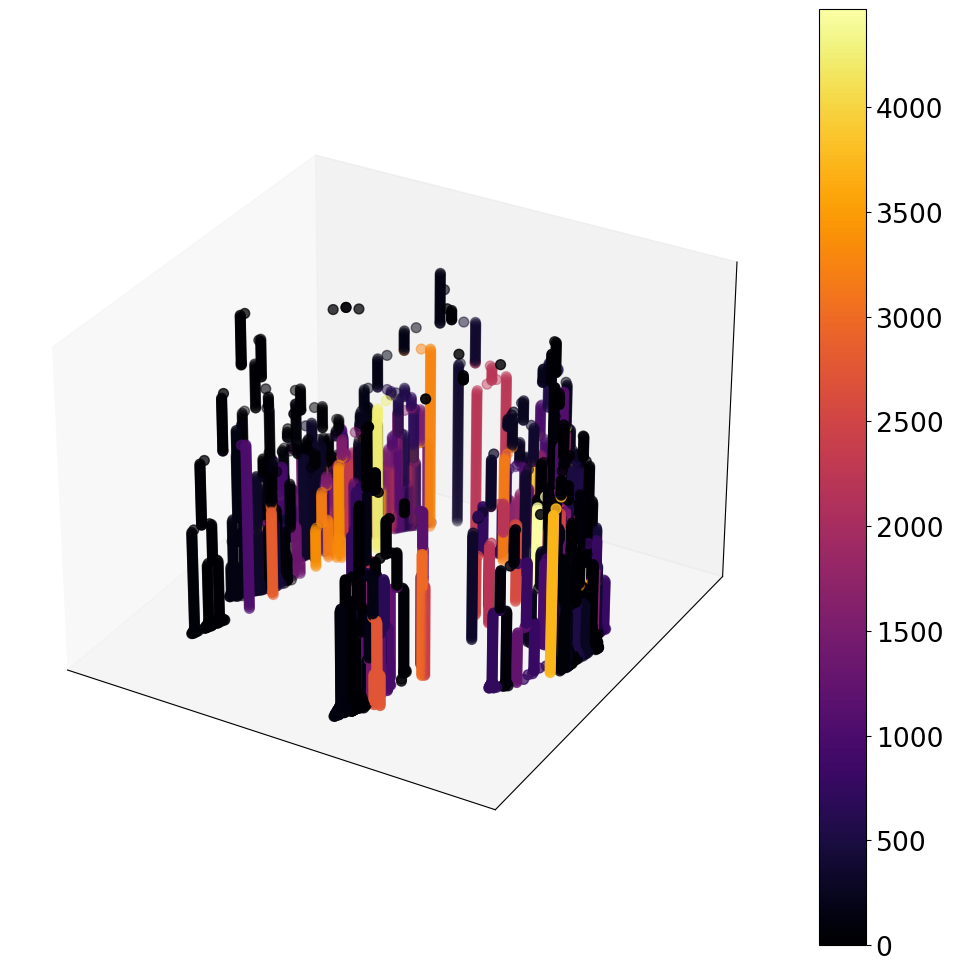

In [14]:
tree_clusters = mp_op.get_tree_clusters(levels[2])

scprep.plot.scatter3d(tree, c = tree_clusters, s= 50,
                      fontsize=16, ticks=False, figsize=(10,10))

In [21]:
coarse_embedding, coarse_clusters, coarse_sizes = mp_op.transform(visualization_level = levels[2],
                                                                  cluster_level = levels[7])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: xlabel='Multiscale PHATE1', ylabel='Multiscale PHATE2'>

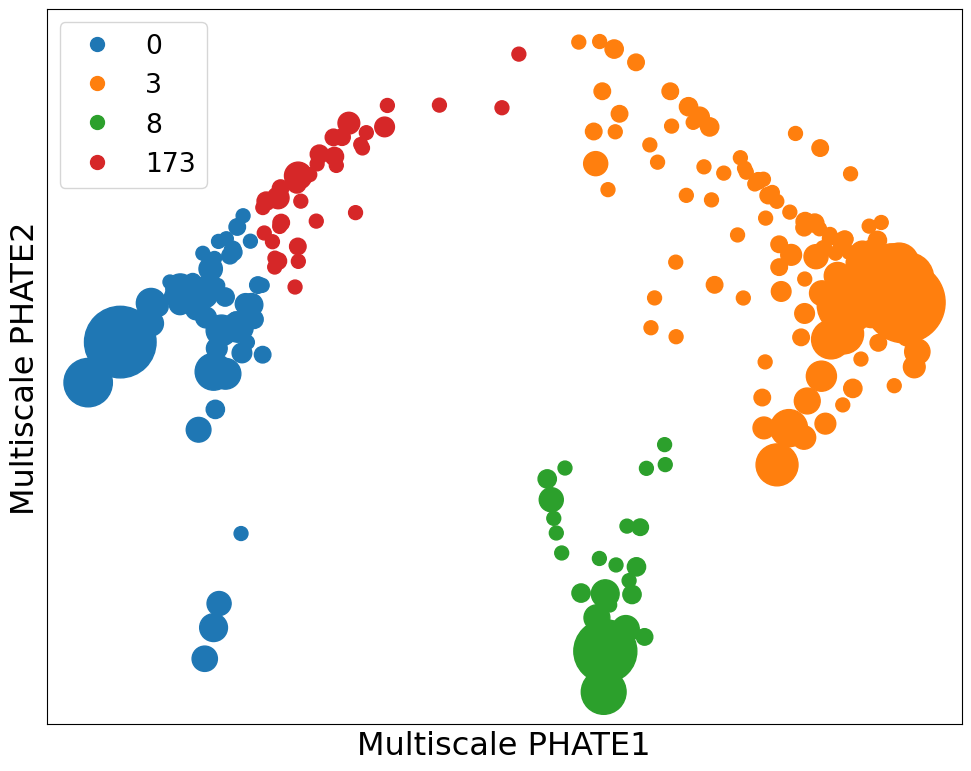

In [22]:
scprep.plot.scatter2d(coarse_embedding, s = 100*np.sqrt(coarse_sizes), c = coarse_clusters,
                      fontsize=16, ticks=False,label_prefix="Multiscale PHATE", figsize=(10,8))

In [31]:
coarse_expression = pd.DataFrame()
coarse_expression['CD3E'] = mp_op.get_expression(data_sqrt['CD3E (ENSG00000198851)'].values,
                                                 visualization_level =  levels[2])
coarse_expression['CD19'] = mp_op.get_expression(data_sqrt['CD19 (ENSG00000177455)'].values,
                                                 visualization_level =  levels[2])
coarse_expression['CD14'] = mp_op.get_expression(data_sqrt['CD14 (ENSG00000170458)'].values,
                                                 visualization_level =  levels[2])

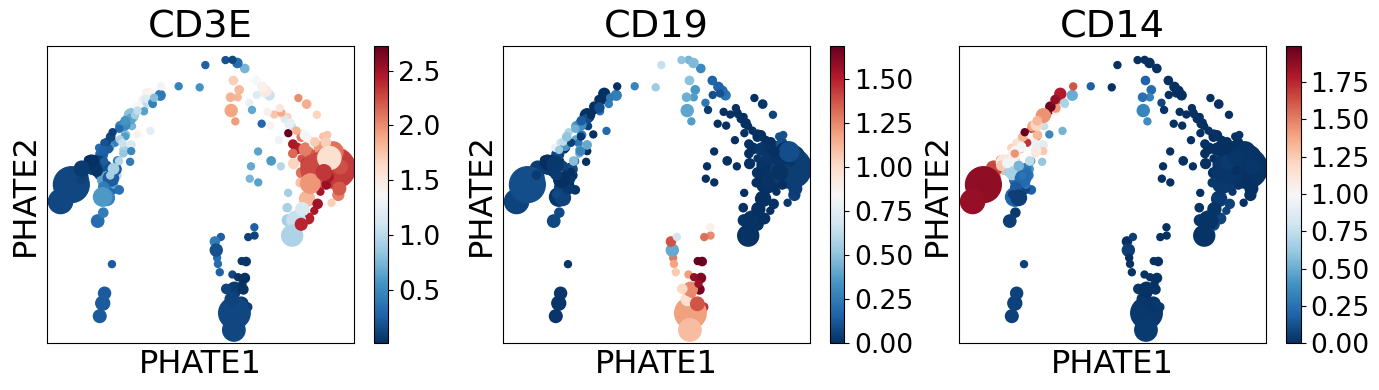

In [32]:
fig, axes = plt.subplots(1,3, figsize=(14, 4))

genes = ['CD3E', 'CD19', 'CD14']

for i, ax in enumerate(axes.flatten()):
    scprep.plot.scatter2d(coarse_embedding, s = 25*np.sqrt(coarse_sizes),
                          c=coarse_expression[genes[i]], legend_anchor=(1,1), ax=ax, title=genes[i],
                          xticks=False, yticks=False, label_prefix="PHATE", fontsize=16, cmap = 'RdBu_r')

fig.tight_layout()


In [23]:
zoom_embedding, zoom_clusters, zoom_sizes =  mp_op.transform(visualization_level=levels[1],
                                                             cluster_level=levels[2],
                                                             coarse_cluster_level=levels[7],
                                                             coarse_cluster=3)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: xlabel='Multiscale PHATE1', ylabel='Multiscale PHATE2'>

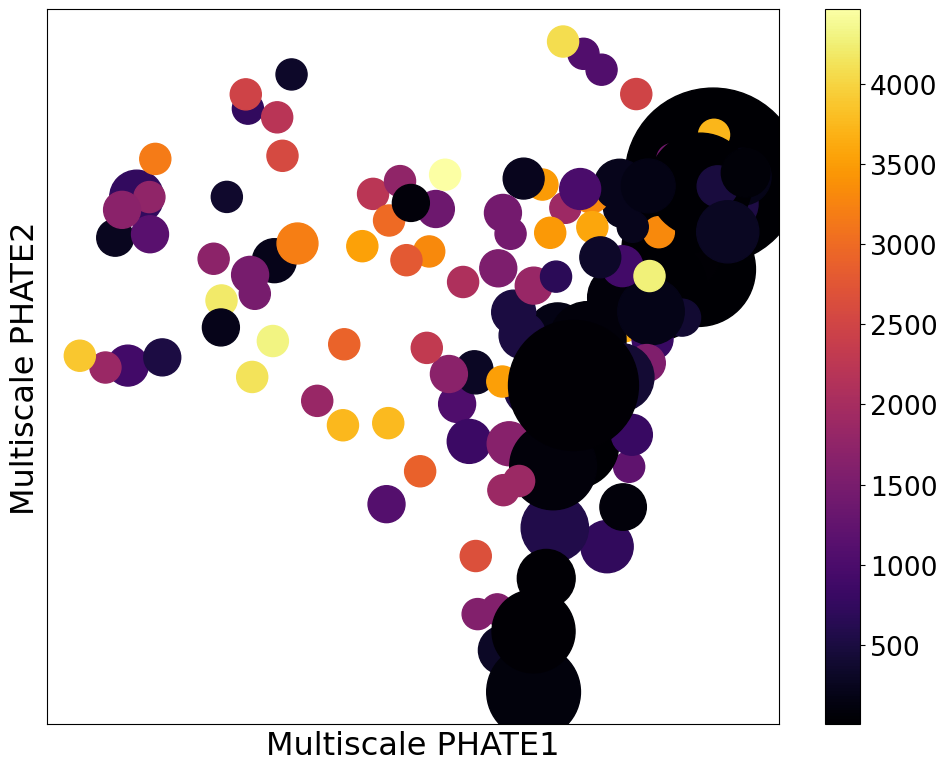

In [24]:
scprep.plot.scatter2d(zoom_embedding, s = 500*np.sqrt(zoom_sizes), c = zoom_clusters,
                      fontsize=16, ticks=False,label_prefix="Multiscale PHATE", figsize=(10,8))

In [48]:
fine_expression = pd.DataFrame()
fine_expression['CD19'] = mp_op.get_expression(data_sqrt['CD19 (ENSG00000177455)'].values,
                                                 visualization_level =  levels[1],
                                                 coarse_cluster_level=levels[9],
                                                 coarse_cluster=3)
fine_expression['CD27'] = mp_op.get_expression(data_sqrt['CD27 (ENSG00000139193)'].values,
                                                 visualization_level =  levels[1],
                                                 coarse_cluster_level=levels[9],
                                                 coarse_cluster=3)
fine_expression['CD20'] = mp_op.get_expression(data_sqrt['MS4A1 (ENSG00000156738)'].values,
                                                 visualization_level =  levels[1],
                                                 coarse_cluster_level=levels[9],
                                                 coarse_cluster=3)

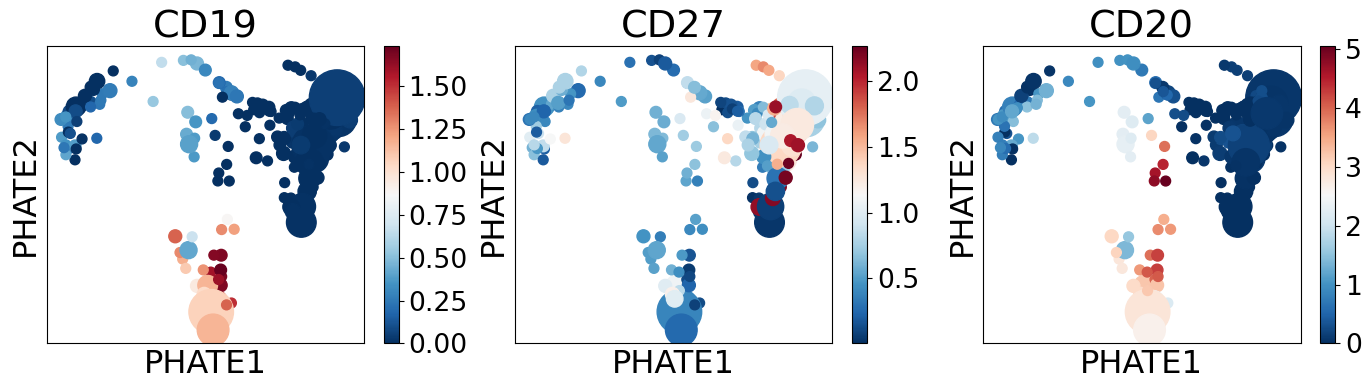

In [49]:
fig, axes = plt.subplots(1,3, figsize=(14, 4))

genes = ['CD19','CD27','CD20']

for i, ax in enumerate(axes.flatten()):
    scprep.plot.scatter2d(zoom_embedding, s = 50*np.sqrt(zoom_sizes),
                          c=fine_expression[genes[i]], legend_anchor=(1,1), ax=ax, title=genes[i],
                          xticks=False, yticks=False, label_prefix="PHATE", fontsize=16, cmap = 'RdBu_r')

fig.tight_layout()